#Universidad del Gran Rosario - UGR
#Ingeniería del Software
##Trabajo Práctico
###Introducción a las metodologías y procesos de Ciencia de Datos
####Docentes: Ing. Ignacio Sanseovich - Lic. Briant Gauna

####Estudiantes:
*   Gisela Martinez
*   Noelia Cualina
*   Javier Carabajal
*   Leonardo Carabajal
*   Nicolas Suarez
*   Marcelo Delgado
*   Ezequias Bonvissuto
*   Pedro Roberti


###Estudio de Caso
Este trabajo se basa en la aplicación de una metodología de Minería de Datos y su implementación en una solución de software.

Lo que se espera es que el grupo desarrolle:
* Una metodología clara de cómo se procesarán los datos y su resultado e interpretación.
* Las vistas y montaje de la solución de software que dará vida a esta metodología para conectar el proceso de datos con el usuario final.

Elegiremos trabajar con la Metodología CRISP-DM (Cross-Industry Standard Process for Data Mining).

La entrega constará de:
* Esta notebook completa
* El link desde donde se puede acceder al producto de software implementado
https://chronosxv.github.io/Ingenieria_Software/

##Fases del Trabajo:

#Fase #1: Comprensión del Negocio / Business Understanding:
Esta fase inicial se centra en comprender los objetivos y requisitos del proyecto desde una perspectiva de negocio, para luego convertir este conocimiento en una definición del problema de minería de datos y un plan preliminar diseñado para lograr los objetivos.

* Elegí un problema de negocio que puedas resolver con datos. Describilo brevemente.
* ¿Cuál es el objetivo principal del análisis? Elaborá un objetivo general y algunos específicos. Te ayudarán a clasificar las tareas más adelante.
* Enumerá los distintos Stakeholders del negocio donde está inmerso el problema.
* ¿Qué impacto tendrá la solución en el negocio o en la toma de decisiones? Justificála realización del estudio desde la perspectiva de cada Stakeholder enumerado anteriormente.
* **Pregunta guía: ¿Qué variables permiten anticipar el tipo de delito y qué zonas/horarios concentran mayor riesgo?**

###A1. Descripción del problema de negocio:

La inseguridad urbana representa una de las principales problemáticas que afectan a la Ciudad Autónoma de Buenos Aires. Los delitos como robos, hurtos, lesiones y homicidios impactan directamente en la calidad de vida de los ciudadanos y en la percepción de seguridad dentro de la ciudad.

A partir del análisis de datos abiertos proporcionados por el Gobierno de la Ciudad de Buenos Aires, se buscará identificar patrones espaciales y temporales en los delitos ocurridos durante el año 2025. Esto permitirá detectar zonas críticas, franjas horarias de mayor riesgo y tipos de delitos más frecuentes.

La problemática elegida consiste en desarrollar una solución basada en datos que permita analizar el comportamiento delictivo y facilitar la toma de decisiones preventivas y estratégicas.

###A2. Objetivos del análisis:

Objetivo General:

Analizar los delitos registrados en la Ciudad de Buenos Aires durante el año 2025 para identificar patrones, tendencias y zonas de mayor incidencia delictiva mediante técnicas de análisis de datos.

Objetivos Específicos:

*   Identificar cuáles son los delitos más frecuentes registrados en la ciudad.
*   Detectar las comunas o barrios con mayor concentración de delitos.
*   Analizar las franjas horarias y días con mayor actividad delictiva.
*   Evaluar si existen patrones temporales relacionados con determinados tipos de delitos.
*   Generar visualizaciones y métricas que faciliten la interpretación de los datos.
*   Diseñar una solución de software que permita consultar y visualizar la información de manera interactiva.

###A3. Stakeholders involucrados:

Los principales stakeholders involucrados en este proyecto son:

*   Gobierno de la Ciudad de Buenos Aires.
*   Fuerzas de seguridad y policía.
*   Ciudadanos y vecinos.
*   Comercios y empresas ubicadas en zonas afectadas.
*   Analistas de datos y organismos de planificación urbana.
Equipos de desarrollo de software encargados de implementar la solución.


###A4. Impacto de la solución en el negocio y toma de decisiones:

Gobierno de la Ciudad:

La solución permitirá obtener información basada en datos reales para mejorar la planificación de políticas públicas y estrategias de prevención del delito.

Fuerzas de Seguridad:

Podrán identificar zonas y horarios críticos para optimizar la distribución de patrullajes y recursos policiales.

Ciudadanos:

Los ciudadanos tendrán acceso a información relevante sobre seguridad en distintas zonas de la ciudad, lo que puede ayudar en la toma de decisiones cotidianas y en la percepción de seguridad.

Comercios y Empresas:

La información obtenida puede servir para evaluar riesgos en determinadas zonas y tomar medidas preventivas relacionadas con horarios, logística o seguridad privada.

Analistas y Planificadores Urbanos:

El análisis facilitará la detección de tendencias y permitirá realizar estudios complementarios sobre comportamiento urbano y seguridad.

Equipo de Desarrollo:

La implementación de una solución de software permitirá conectar el análisis de datos con una interfaz accesible e interactiva para los usuarios finales, mejorando la disponibilidad y comprensión de la información.

#Fase #2: Comprensión de los Datos / Data Understanding
La fase de comprensión de datos comienza con una recopilación inicial de datos y continúa con actividades para familiarizarse con los datos, identificar problemas de calidad de los datos, descubrir los primeros conocimientos sobre los datos o detectar subconjuntos interesantes para formular hipótesis sobre información oculta.
* Establecé una metodología de adquisición de los datos para el negocio.
* Contemplá en la adquisición de datos una alternativa donde debas construir el set de datos.
* Identificá los distintos problemas o desafíos con los datos (datos faltantes, ruidos,etc) que puedan afectar a su calidad.
* Enumerá las distintas fases, tareas generales, tareas específicas e instancias del proceso que incluirás como estrategia para aplicar la metodología

# Librerias importadas

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import userdata
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


## Inicializacion del repositorio GIT

In [ ]:
# Seteo de variables para seteo de config globals para git
git_email: str = userdata.get('git_email')
git_name: str = userdata.get('git_name')
git_token: str = userdata.get('git_token')

In [ ]:
# Seleccion de branch por integrantes del equipo
branch_name_ing: str = userdata.get('branch_name_ing')

In [ ]:
# Setear la config global de git
!git config --global user.email {git_email}
!git config --global user.name {git_name}

In [ ]:
# Ejecutamos el comando git clone y descargamos nuestro repositorio
!git clone https://github.com/ChronosXV/Ingenieria_Software.git

fatal: destination path 'Ingenieria_Software' already exists and is not an empty directory.


In [ ]:
# Me posiciono sobre el repositorio para comenzar a usar comandos git
current_dir = os.getcwd()
repo_path = 'Ingenieria_Software'

# Verificar si ya estamos en el directorio
if os.path.basename(current_dir) == repo_path:
    print(f"Ya estamos en el directorio: {current_dir}")
elif os.path.exists(repo_path) and os.path.isdir(repo_path):
    os.chdir(repo_path)
    print(f"Cambiado al directorio: {os.getcwd()}")
else:
    print(f"El directorio {repo_path} no existe o no se puede acceder.")

Ya estamos en el directorio: /content/Ingenieria_Software


In [ ]:
# Nos posicionamos en nuestra branch
!git checkout "{branch_name_ing}"
# Validamos que estemos en nuestra branch
!git branch

Already on 'Ing_Software'
Your branch is up to date with 'origin/Ing_Software'.
* Ing_Software
  main


In [ ]:
# F2. Creamos el df con los datos de nuestro dataSet para poder analizar los datos
df_delitos = pd.read_excel('/content/Ingenieria_Software/Proyecto/DataSet_Original/delitos_2025.xlsx')


In [ ]:
# Descripcion de la estructura del dataset:
print("\nEstructura del Dataset")
print(f"El dataset tiene {df_delitos.shape[0]} filas y {df_delitos.shape[1]} columnas.")


Estructura del Dataset
El dataset tiene 133203 filas y 15 columnas.


In [ ]:
# Mostramos las Primeras 5 filas de nuestro DataFrame
display(df_delitos.head())

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
0,1591961,2025,FEBRERO,DOMINGO,2025-02-02,14.0,Homicidios,Homicidios dolosos,NO,NO,CABALLITO,6.0,-3461534.0,-58431076.0,1
1,1591962,2025,ENERO,DOMINGO,2025-01-12,1.0,Homicidios,Homicidios dolosos,NO,NO,RETIRO,1.0,-34583965.0,-58379769.0,1
2,1591963,2025,DICIEMBRE,MIERCOLES,2025-12-10,4.0,Homicidios,Homicidios dolosos,NO,NO,BARRACAS,4.0,-34650457.0,-58404647.0,1
3,1591964,2025,ENERO,LUNES,2025-01-20,0.0,Homicidios,Homicidios dolosos,NO,NO,VILLA LUGANO,8.0,-34682057.0,-58488847.0,1
4,1591965,2025,DICIEMBRE,VIERNES,2025-12-12,23.0,Homicidios,Homicidios dolosos,NO,NO,MONSERRAT,1.0,-34608938.0,-58387545.0,1


In [ ]:
# Verificamos el tipo de dato de nuestras variables
df_delitos.dtypes

,0
id-mapa,int64
anio,int64
mes,object
dia,object
fecha,datetime64[ns]
franja,float64
tipo,object
subtipo,object
uso_arma,object
uso_moto,object


Clasificación de Variables y Tipos de Datos.

Tras la carga inicial del dataset, realizamos una categorización técnica de las variables para definir la estrategia de procesamiento y análisis posterior:

1. Variables Cuantitativas (Numéricas)
Estas serán la base para cálculos estadísticos y georreferenciación.

        * Identificadores: id-mapa
        * Geolocalización: latitud, longitud
        * Métricas: cantidad
        * Atributos de Orden: anio, franja, comuna

2. Variables Cualitativas (Categóricas)
Con estos datos podremos encontrar patrones de comportamiento.

        * Descriptivas: tipo, subtipo, barrio
        * Operativas: uso_arma, uso_moto
        * Temporales: mes, dia

3. Variables de Objeto (Temporal)

        * fecha: Se identifica como la variable raíz para la cual podremos realizar análisis de series temporales, permitiendo una granularidad diaria en la evolución delictiva.

In [ ]:
# Cantidad de datos nulos por columna
df_delitos.isnull().sum()

,0
id-mapa,0
anio,0
mes,0
dia,0
fecha,0
franja,155
tipo,0
subtipo,0
uso_arma,0
uso_moto,0


El conjunto de datos presenta valores nulos significativos en varias columnas. Se observa que 'franja' tiene 155 valores faltantes, mientras que 'barrio' y 'comuna' carecen de 2785 valores cada una. Además, 'latitud' y 'longitud' tienen 265 entradas nulas

In [ ]:
# Realizar un análisis preliminar de calidad: porcentaje de datos faltantes por variable, detección de posibles inconsistencias.

nulos_totales = df_delitos.isnull().sum()
porcentaje_nulos = (nulos_totales / len(df_delitos)) * 100

# Armamos un cuadro resumen
calidad_df = pd.DataFrame({
    'Columna': nulos_totales.index,
    'Cantidad de Nulos': nulos_totales.values,
    'Porcentaje (%)': porcentaje_nulos.values
}).sort_values(by='Porcentaje (%)', ascending=False)

# Mostramos el resumen
print("Análisis de datos faltantes por variable:")
display(calidad_df)

Análisis de datos faltantes por variable:


,Columna,Cantidad de Nulos,Porcentaje (%)
10,barrio,2785,2.090794
11,comuna,2785,2.090794
12,latitud,265,0.198944
13,longitud,265,0.198944
5,franja,155,0.116364
1,anio,0,0.000000
0,id-mapa,0,0.000000
6,tipo,0,0.000000
4,fecha,0,0.000000
3,dia,0,0.000000


Podemos observar porcentajes bajos de nulos. Con mayores valores encontramos a las variables 'barrio' y 'comuna' con un porcentaje de (2.09%), seguidas por 'latitud' y 'longitud' (0.19%), y por ultimo 'franja' (0.11%).

In [ ]:
# Verificamos si tenemos datos duplicados
print(f"Cantidad de filas duplicadas: {df_delitos.duplicated().sum()}")

Cantidad de filas duplicadas: 0


No se observan datos duplicados en el dataSet

In [ ]:
# Verificacion de variable Subtipo
print("Cantidad de delitos por tipo y subtipo:")
display(df_delitos.groupby(['tipo','subtipo']).size().sort_values(ascending=False))

Cantidad de delitos por tipo y subtipo:


,,0
tipo,subtipo,
Robo,Robo total,49545
Hurto,Hurto total,45102
Vialidad,Lesiones por siniestros viales,11669
Lesiones,Lesiones Dolosas,11544
Amenazas,Amenazas,10111
Hurto,Hurto automotor,4539
Robo,Robo automotor,524
Vialidad,Muertes por siniestros viales,91
Homicidios,Homicidios dolosos,78



Distribución de los tipos de delitos:


,count
tipo,
Robo,50069
Hurto,49641
Vialidad,11760
Lesiones,11544
Amenazas,10111
Homicidios,78


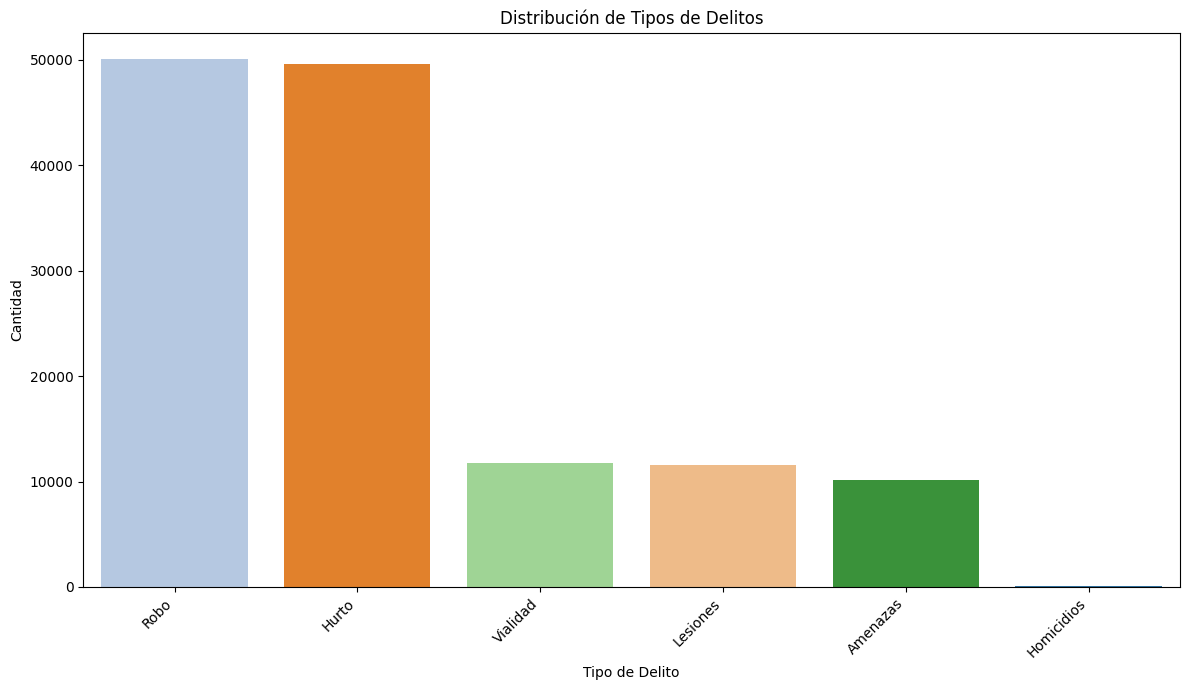

In [ ]:
# Descubrir los primeros conocimientos sobre los datos o detectar subconjuntos interesantes
# Análisis de la distribución de los tipos de delitos
print("\nDistribución de los tipos de delitos:")
display(df_delitos['tipo'].value_counts())

# Visualización de los tipos de delitos más frecuentes (vertical con color azul marino)
plt.figure(figsize=(12, 7))
sns.countplot(x='tipo', data=df_delitos, order=df_delitos['tipo'].value_counts().index, hue='tipo', palette='tab20', legend=False)
plt.title('Distribución de Tipos de Delitos')
plt.xlabel('Tipo de Delito')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout() # Ajustar el diseño para evitar el solapamiento de etiquetas
plt.show()

Este gráfico de barras tenemos una rapida visualizacion por delito.


Top 10 barrios con mayor incidencia delictiva:


,count
barrio,
PALERMO,10607
BALVANERA,7782
FLORES,7255
CABALLITO,5953
RECOLETA,5421
ALMAGRO,4908
BARRACAS,4678
SAN NICOLAS,4592
VILLA LUGANO,4549


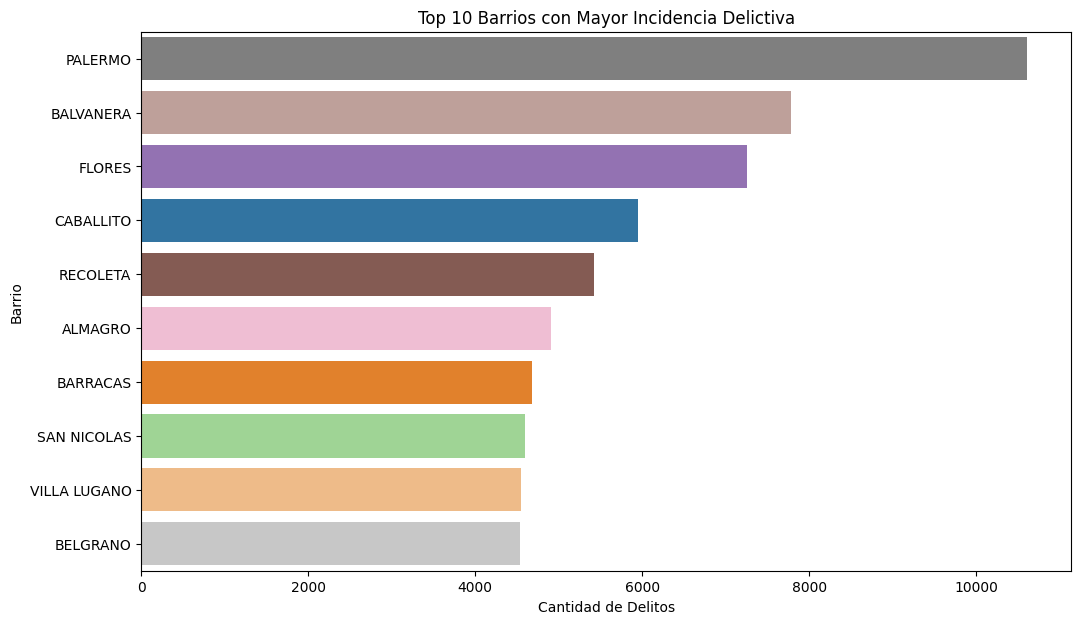

In [ ]:
# Visualización de los barrios con mayor incidencia
print("\nTop 10 barrios con mayor incidencia delictiva:")
display(df_delitos['barrio'].value_counts().head(10))

plt.figure(figsize=(12, 7))
sns.countplot(y='barrio', data=df_delitos, order=df_delitos['barrio'].value_counts().head(10).index, hue='barrio', palette='tab20', legend=False)
plt.title('Top 10 Barrios con Mayor Incidencia Delictiva')
plt.xlabel('Cantidad de Delitos')
plt.ylabel('Barrio')
plt.show()

### Visualizaciones adicionales de distribución:


Distribución de delitos por mes:


,count
mes,
MARZO,12040
OCTUBRE,11530
ENERO,11511
MAYO,11448
NOVIEMBRE,11281
ABRIL,11130
DICIEMBRE,11069
JULIO,11010
FEBRERO,10740


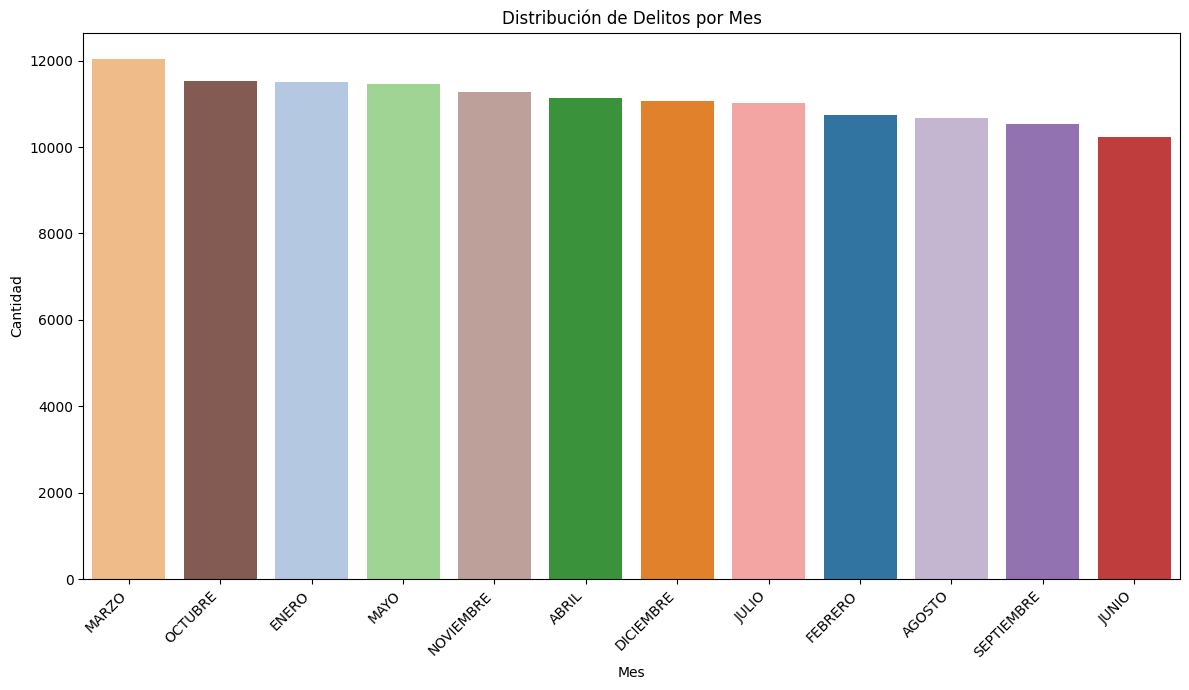

In [ ]:
# Distribución de delitos por mes
print("\nDistribución de delitos por mes:")
display(df_delitos['mes'].value_counts())

plt.figure(figsize=(12, 7))
sns.countplot(x='mes', data=df_delitos, order=df_delitos['mes'].value_counts().index, hue='mes', palette='tab20', legend=False)
plt.title('Distribución de Delitos por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Distribución de delitos por día de la semana:


,count
dia,
VIERNES,20591
MIERCOLES,19726
JUEVES,19609
MARTES,19254
LUNES,19179
SABADO,18560
DOMINGO,16284


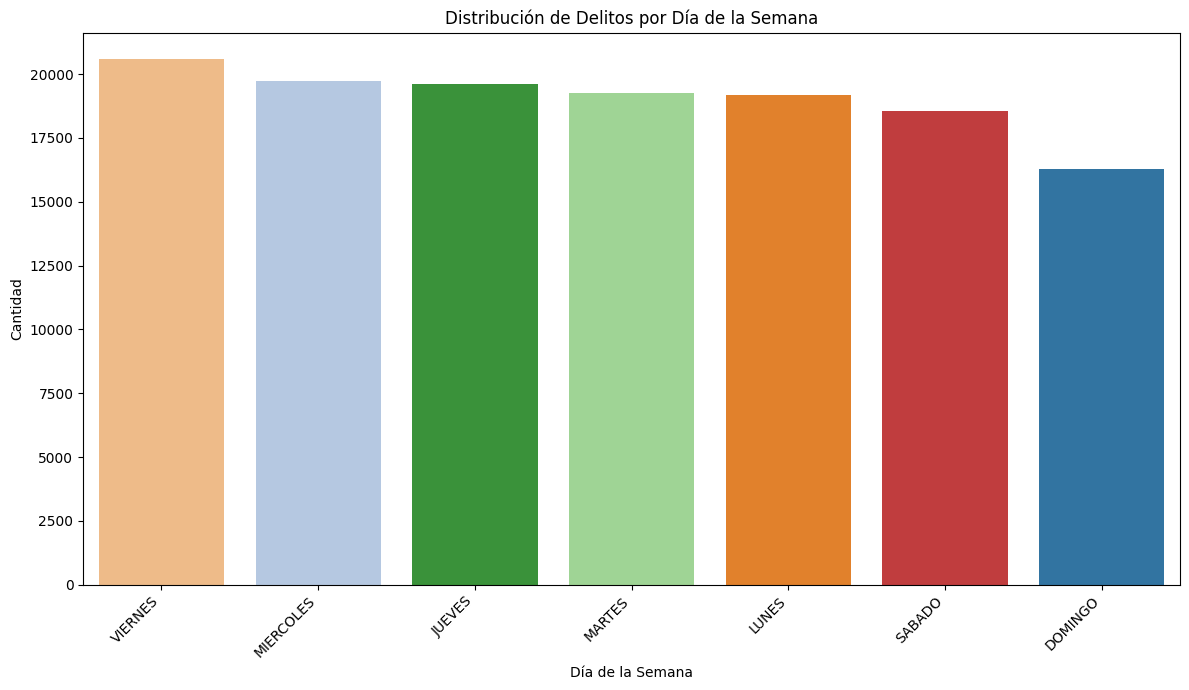

In [ ]:
# Distribución de delitos por día de la semana
print("\nDistribución de delitos por día de la semana:")
display(df_delitos['dia'].value_counts())

plt.figure(figsize=(12, 7))
sns.countplot(x='dia', data=df_delitos, order=df_delitos['dia'].value_counts().index, hue='dia', palette='tab20', legend=False)
plt.title('Distribución de Delitos por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Distribución de delitos por franja horaria:


,count
franja,
0.0,4705
1.0,2858
2.0,2550
3.0,2356
4.0,2407
5.0,2709
6.0,3761
7.0,5552
8.0,6388


/tmp/ipykernel_1329/1580042210.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_delitos['franja'].dropna(), bins=24, kde=False, palette='viridis')


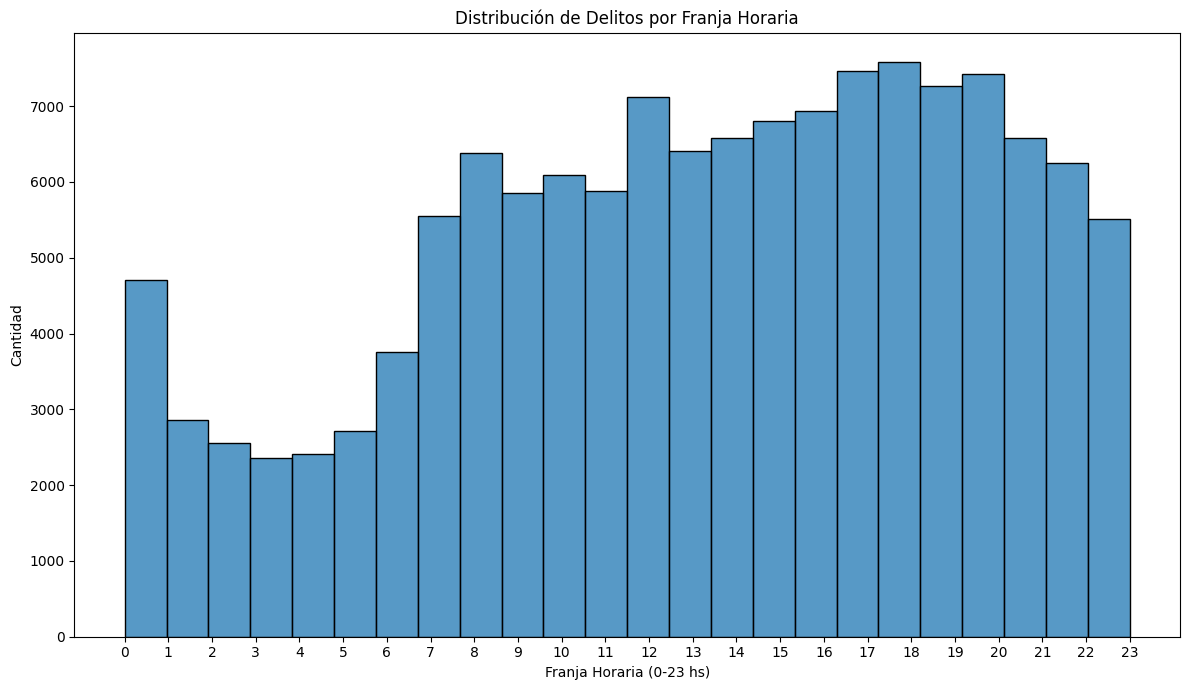

In [ ]:
# Distribución de delitos por franja horaria
print("\nDistribución de delitos por franja horaria:")
display(df_delitos['franja'].value_counts().sort_index())

plt.figure(figsize=(12, 7))
sns.histplot(df_delitos['franja'].dropna(), bins=24, kde=False, palette='viridis')
plt.title('Distribución de Delitos por Franja Horaria')
plt.xlabel('Franja Horaria (0-23 hs)')
plt.ylabel('Cantidad')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


Distribución de delitos por comuna:


,count
comuna,
1.0,18907
2.0,5421
3.0,9863
4.0,12281
5.0,6712
6.0,5953
7.0,10209
8.0,8399
9.0,7355


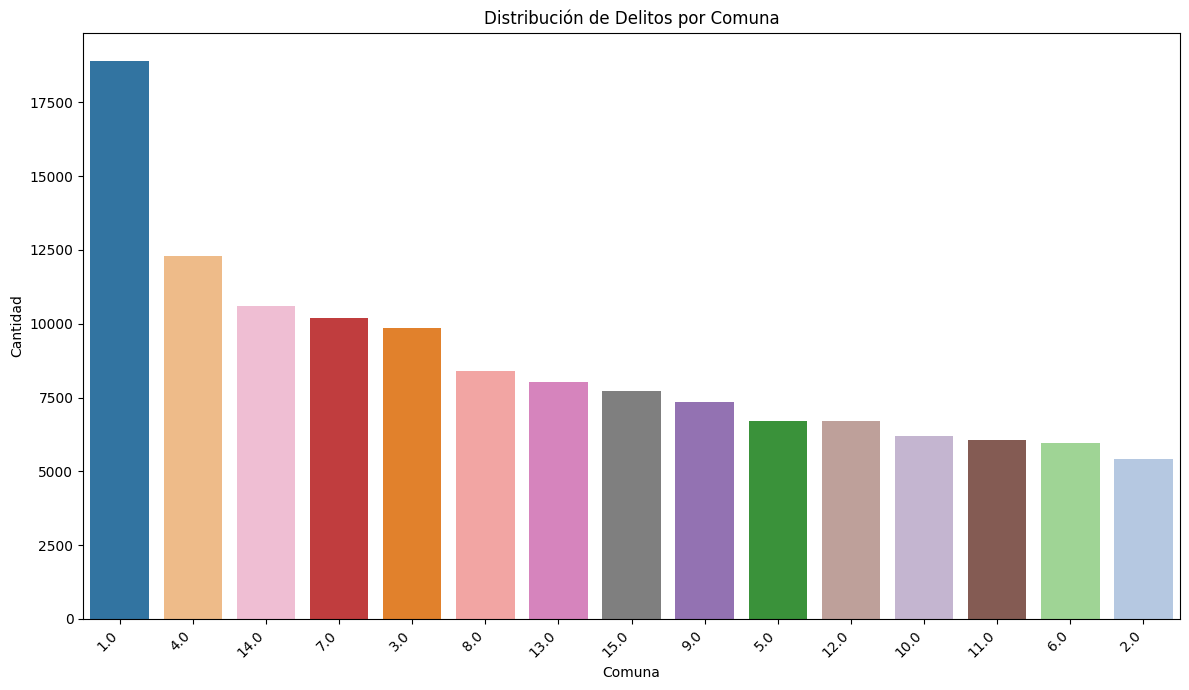

In [ ]:
# Distribución de delitos por comuna
print("\nDistribución de delitos por comuna:")
display(df_delitos['comuna'].value_counts().sort_index())

plt.figure(figsize=(12, 7))
sns.countplot(x='comuna', data=df_delitos, order=df_delitos['comuna'].value_counts().index, hue='comuna', palette='tab20', legend=False)
plt.title('Distribución de Delitos por Comuna')
plt.xlabel('Comuna')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Distribución de uso de arma:


,count
uso_arma,
NO,127637
SI,5566


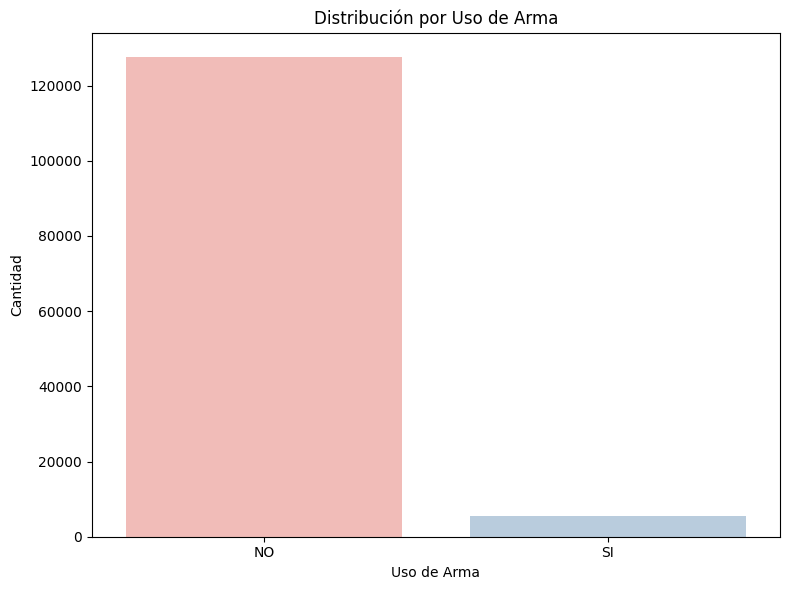

In [ ]:
# Análisis de 'uso_arma'
print("\nDistribución de uso de arma:")
display(df_delitos['uso_arma'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='uso_arma', data=df_delitos, order=df_delitos['uso_arma'].value_counts().index, hue='uso_arma', palette='Pastel1', legend=False)
plt.title('Distribución por Uso de Arma')
plt.xlabel('Uso de Arma')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()


Distribución de uso de moto:


,count
uso_moto,
NO,127616
SI,5587


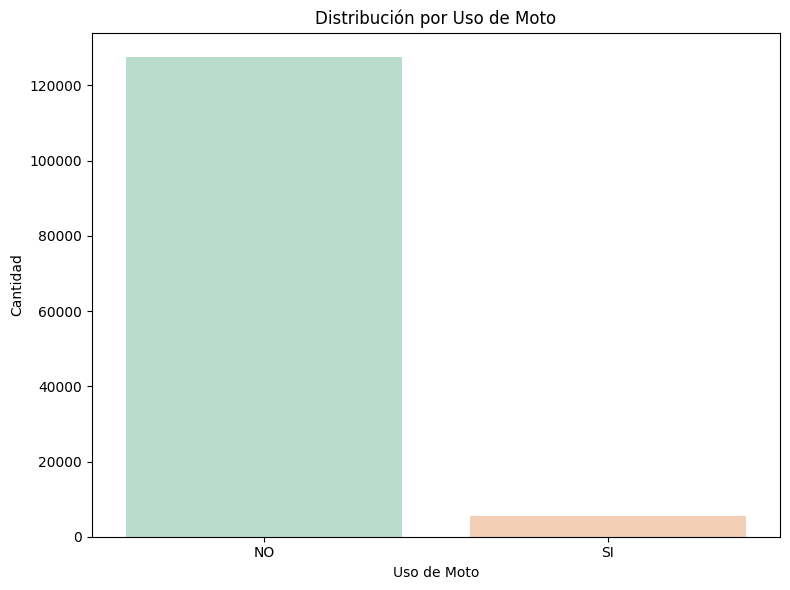

In [ ]:
# Análisis de 'uso_moto'
print("\nDistribución de uso de moto:")
display(df_delitos['uso_moto'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='uso_moto', data=df_delitos, order=df_delitos['uso_moto'].value_counts().index, hue='uso_moto', palette='Pastel2', legend=False)
plt.title('Distribución por Uso de Moto')
plt.xlabel('Uso de Moto')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

Aca podemos observar el top 10  de barrios con la mayor incidencia delictiva en la Ciudad de Buenos Aires.

## A.1 Metodología de adquisición

    •	Identificación de Fuentes de Datos: Se identificarán las principales fuentes de datos para el análisis de delitos. La fuente principal es el dataset 'delitos_2025.xlsx' proporcionado por el Gobierno de la Ciudad de Buenos Aires.
  
    •	Consideraciones de Frecuencia y Automatización: Actualmente, la adquisición es puntual para el dataset 'delitos_2025.xlsx'. Para futuras actualizaciones, se establecerá una frecuencia de adquisición que será  mensual(a mes vencido). Se explorará la posibilidad de automatizar el proceso de descarga y carga de datos mediante scripts programados, especialmente si las fuentes ofrecen APIs que permitan un acceso recurrente y estructurado.

    •	Plan de Almacenamiento Inicial: Los datos adquiridos, una vez consolidados en un DataFrame de Pandas, se almacenarán localmente en el entorno de Colab durante la fase de desarrollo. Para una solución de negocio, se considerará un almacenamiento más robusto, como bases de datos relacionales (ej. PostgreSQL) o no relacionales, o incluso soluciones de almacenamiento en la nube, para asegurar la persistencia y accesibilidad de los datos.




## A.2 Alternativa de Datos (Creacion de DataSet)

    •	Herramientas de Adquisición: La adquisición inicial se realizará mediante la carga directa del archivo 'delitos_2025.xlsx' utilizando la librería Pandas en Python, como ya se ha demostrado en este Colab. En caso alternativos para la construccion de datos de  fuentes podremos utilizar (APIs), y  emplear scripts de Python para realizar solicitudes HTTP, como asi tambien podemos utilizar metodos como web scraping y procesar las respuestas en formatos como JSON o CSV, transformándolos posteriormente a DataFrames de Panda.

## A.3 Estrategia para Datos Faltantes
    •	Estrategia para Datos Faltantes o No Estructurados: Durante la adquisición, se prestará atención a los datos faltantes o inconsistencias. Si se integran nuevas fuentes, se realizará una fase preliminar para estandarizar formatos y resolver posibles conflictos de esquemas. La estrategia incluirá la documentación de los datos faltantes y una primera revisión de su impacto antes de la fase de preparación de datos.

## A.4 Implementacion
    * Refinar Visualización de Distribución de Delitos por Mes
    * Analizar el Impacto de Datos Faltantes
    * Describir Variables Relevantes
    * Realizar Estadísticas Descriptivas y Visualizaciones
    * Realizar una conclusion final

#Fase #3: Preparación de los Datos / Data Preparation
La fase de preparación de datos abarca todas las actividades para construir el conjunto de datos final (datos que se introducirán en las herramientas de modelado) a partir de los datos brutos iniciales. Es probable que las tareas de preparación de datos se realicen varias veces y no en ningún orden prescrito. Las tareas incluyen la selección de tablas, registros y atributos, así como la transformación y limpieza de datos para herramientas de modelado.
* Enumerá y describí las variables relevantes que son de tu interés para el estudio.Por ejemplo, edad: es la edad en años cumplidos al 31 de diciembre de 2024, es una variable continua discreta.
* Armá una tabla que resuma el análisis estadístico descriptivo y los gráficos que realizarás para entender las características de los datos.

En esta fase se realizará la preparación y exploración de los datos con el objetivo de construir un conjunto de datos consistente y apto para el análisis. Se aplicarán tareas de limpieza, validación y análisis exploratorio (EDA) para identificar patrones, distribuciones y posibles inconsistencias dentro del dataset de delitos de la Ciudad de Buenos Aires.


Las actividades principales incluirán:

*  Selección de variables relevantes.
*  Tratamiento de datos faltantes.
*  Verificación de inconsistencias.
*  Conversión y validación de tipos de datos.
*  Generación de métricas descriptivas.
*  Construcción de visualizaciones exploratorias.
*  Preparación de los datos para futuras etapas de modelado y visualización.

## A1. Enumeracíon de variables:

Para el análisis delictivo se seleccionaron aquellas variables que aportan información temporal, geográfica y descriptiva sobre los hechos registrados. Estas variables permitirán identificar patrones espaciales y temporales, así como tendencias relacionadas con los distintos tipos de delitos.

| Variable | Tipo de Variable                      | Descripción                                  | Utilidad en el análisis                              |
| -------- | ------------------------------------- | -------------------------------------------- | ---------------------------------------------------- |
| id-mapa  | Cuantitativa discreta (identificador) | Identificador único del registro del delito. | Permite diferenciar cada observación del dataset.    |
| fecha    | Temporal                              | Fecha exacta del hecho delictivo.            | Análisis temporal y evolución de delitos.            |
| anio     | Cuantitativa discreta                 | Año del registro del delito.                 | Segmentación temporal general.                       |
| mes      | Cualitativa ordinal                   | Mes en el que ocurrió el delito.             | Identificación de patrones mensuales.                |
| dia      | Cualitativa nominal                   | Día de la semana del hecho.                  | Detección de días con mayor actividad delictiva.     |
| franja   | Cuantitativa discreta                 | Franja horaria (0–23 hs).                    | Análisis de horarios críticos.                       |
| tipo     | Cualitativa nominal                   | Categoría general del delito.                | Identificación de delitos más frecuentes.            |
| subtipo  | Cualitativa nominal                   | Clasificación específica del delito.         | Análisis detallado del comportamiento delictivo.     |
| barrio   | Cualitativa nominal                   | Barrio donde ocurrió el hecho.               | Identificación de zonas críticas.                    |
| comuna   | Cuantitativa discreta                 | Comuna correspondiente al hecho.             | Análisis geográfico y comparativo.                   |
| latitud  | Cuantitativa continua                 | Coordenada geográfica de ubicación.          | Georreferenciación y mapas.                          |
| longitud | Cuantitativa continua                 | Coordenada geográfica de ubicación.          | Georreferenciación y mapas.                          |
| uso_arma | Cualitativa binaria                   | Indica si hubo utilización de arma.          | Evaluación de gravedad y características del delito. |
| uso_moto | Cualitativa binaria                   | Indica si intervino una motocicleta.         | Identificación de modalidades delictivas.            |
| cantidad | Cuantitativa discreta                 | Cantidad de hechos registrados.              | Métricas y agregaciones estadísticas.  

**Conclusión sobre las variables seleccionadas:**

Las variables elegidas permiten abordar el análisis desde múltiples perspectivas:

Temporal: fecha, mes, día y franja.

Geográfica: barrio, comuna, latitud y longitud.

Tipológica: tipo y subtipo de delito.

Operativa: uso de arma y uso de motocicleta.

La combinación de estas variables permitirá detectar patrones delictivos, zonas críticas y tendencias temporales relevantes para el estudio.

**Limpieza y transformación de datos:**

Tratamiento de valores faltantes:

Durante la exploración se detectaron valores nulos principalmente en:

*  barrio

*  comuna

*  latitud

*  longitud

*  franja

Para minimizar el impacto sobre el análisis:

Los registros con faltantes geográficos serán evaluados según el tipo de visualización.
Se analizará la posibilidad de imputar o excluir registros dependiendo del contexto analítico.
Se verificará que los porcentajes de nulos no comprometan la representatividad del dataset.

In [ ]:
# Verificación de tipos de datos del dataset

print("Tipos de datos del DataFrame:")
display(df_delitos.dtypes)

Tipos de datos del DataFrame:


,0
id-mapa,int64
anio,int64
mes,object
dia,object
fecha,datetime64[ns]
franja,float64
tipo,object
subtipo,object
uso_arma,object
uso_moto,object


**Validación de tipos de datos:**

Se verificaron los tipos de datos de cada variable para asegurar compatibilidad
con futuros procesos de análisis y modelado.

La variable `fecha` fue interpretada correctamente como tipo datetime,
mientras que las variables geográficas y numéricas presentan formatos adecuados
para cálculos estadísticos y visualizaciones.

In [ ]:
# Conversión y validación de variables

# Conversión explícita de fecha

df_delitos['fecha'] = pd.to_datetime(df_delitos['fecha'])

# Conversión de columnas numéricas

df_delitos['franja'] = pd.to_numeric(df_delitos['franja'], errors='coerce')
df_delitos['comuna'] = pd.to_numeric(df_delitos['comuna'], errors='coerce')

print("Conversión de tipos finalizada.")

Conversión de tipos finalizada.


In [ ]:
# Limpieza de textos

# Normalizamos textos

columnas_texto = ['tipo', 'subtipo', 'barrio', 'dia', 'mes']

for col in columnas_texto:
    df_delitos[col] = df_delitos[col].str.strip().str.upper()

print("Normalización de texto completada.")

Normalización de texto completada.


**Verificación de duplicados:**

Se realizó un análisis de duplicados detectando (Fase #1):

*  0 registros duplicados.

Por lo tanto, no fue necesario aplicar procesos de eliminación de redundancia.

In [ ]:
# Validación de rangos

# Validamos rango horario

print("Valores mínimos y máximos de franja horaria:")
print(df_delitos['franja'].min())
print(df_delitos['franja'].max())

Valores mínimos y máximos de franja horaria:
0.0
23.0


In [ ]:
# Verificamos coordenadas geográficas

display(df_delitos[['latitud', 'longitud']].describe())

,latitud,longitud
count,1.329380e+05,1.329380e+05
mean,-3.430426e+12,-5.320805e+12
std,1.902669e+14,2.784703e+14
min,-3.461830e+16,-5.848884e+16
25%,-3.462210e+09,-5.845466e+09
50%,-3.456924e+09,-5.837816e+09
75%,-3.460912e+07,-5.842750e+07
max,0.000000e+00,0.000000e+00


In [ ]:
# Mostramos la dimensión final del dataset preparado

filas, columnas = df_delitos.shape

print("Dimensión final del dataset preparado:")
print(f"Cantidad de filas (registros): {filas}")
print(f"Cantidad de columnas (variables): {columnas}")

Dimensión final del dataset preparado:
Cantidad de filas (registros): 133203
Cantidad de columnas (variables): 15


## A2. Análisis estadístico descriptivo y visualizaciones:


Tabla resumen de análisis y gráficos:

| Variable | Tipo de análisis | Estadística descriptiva | Visualización |
|---|---|---|---|
| tipo | Frecuencia | Conteo y porcentaje | Gráfico de barras |
| subtipo | Frecuencia | Conteo y ranking | Barras horizontales |
| barrio | Distribución geográfica | Top barrios | Barras horizontales |
| comuna | Distribución territorial | Conteo por comuna | Mapa o barras |
| franja | Distribución temporal | Frecuencia horaria | Histograma |
| fecha | Evolución temporal | Tendencia diaria/mensual | Serie temporal |
| uso_arma | Variable binaria | Proporciones | Pie chart o barras |
| uso_moto | Variable binaria | Proporciones | Pie chart o barras |
| latitud / longitud | Distribución espacial | Concentración geográfica | Heatmap / mapa |
| cantidad | Métrica descriptiva | Media, mediana, máximos | Boxplot |

## A3. Generación de Variables Derivadas (Feature Engineering)

Con el objetivo de mejorar la capacidad predictiva del modelo, se generaron nuevas variables derivadas a partir de los datos originales.

Las principales transformaciones realizadas fueron:



*   Creación de la variable `fin_semana` para identificar hechos ocurridos durante
sábados y domingos.
*   Agrupación de las franjas horarias en categorías más representativas (`madrugada`, `mañana`, `tarde` y `noche`).
*   Conversión de variables temporales categóricas (`mes` y `dia`) a representaciones numéricas.
*   Transformación de variables binarias (`uso_arma` y `uso_moto`) a formato numérico.
*   Tratamiento de valores faltantes en variables geográficas y categóricas.

Estas transformaciones permiten preparar el dataset para etapas de modelado supervisado y mejorar la interpretación de patrones delictivos.


In [ ]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

print("Inicio de generación de variables derivadas")

# ----------------------------------------------------------
# 1. Fin de semana
# ----------------------------------------------------------

df_delitos['fin_semana'] = df_delitos['dia'].isin(['SABADO', 'DOMINGO']).astype(int)

# ----------------------------------------------------------
# 2. Turno del día
# ----------------------------------------------------------

def clasificar_turno(hora):

    if pd.isnull(hora):
        return 'DESCONOCIDO'

    hora = int(hora)

    if 0 <= hora < 6:
        return 'MADRUGADA'

    elif 6 <= hora < 12:
        return 'MAÑANA'

    elif 12 <= hora < 18:
        return 'TARDE'

    else:
        return 'NOCHE'

df_delitos['turno'] = df_delitos['franja'].apply(clasificar_turno)

# ----------------------------------------------------------
# 3. Mes numérico
# ----------------------------------------------------------

mapa_meses = {
    'ENERO': 1,
    'FEBRERO': 2,
    'MARZO': 3,
    'ABRIL': 4,
    'MAYO': 5,
    'JUNIO': 6,
    'JULIO': 7,
    'AGOSTO': 8,
    'SEPTIEMBRE': 9,
    'OCTUBRE': 10,
    'NOVIEMBRE': 11,
    'DICIEMBRE': 12
}

df_delitos['mes_num'] = df_delitos['mes'].map(mapa_meses)

# ----------------------------------------------------------
# 4. Día numérico
# ----------------------------------------------------------

mapa_dias = {
    'LUNES': 1,
    'MARTES': 2,
    'MIERCOLES': 3,
    'JUEVES': 4,
    'VIERNES': 5,
    'SABADO': 6,
    'DOMINGO': 7
}

df_delitos['dia_num'] = df_delitos['dia'].map(mapa_dias)

# ----------------------------------------------------------
# 5. Variables binarias
# ----------------------------------------------------------

df_delitos['uso_arma_bin'] = df_delitos['uso_arma'].fillna('NO').eq('SI').astype(int)

df_delitos['uso_moto_bin'] = df_delitos['uso_moto'].fillna('NO').eq('SI').astype(int)

# ----------------------------------------------------------
# 6. Limpieza de nulos
# ----------------------------------------------------------

df_delitos['comuna'] = df_delitos['comuna'].fillna(-1)

df_delitos['barrio'] = df_delitos['barrio'].fillna('DESCONOCIDO')

print("Features generados correctamente")

Inicio de generación de variables derivadas
Features generados correctamente


### Clarificación del tratamiento de nulos y coordenadas

**Manejo de Valores Nulos:**

Como se mencionó en la fase de Comprensión de Datos, las columnas `barrio`, `comuna`, `latitud`, `longitud` y `franja` presentaban valores nulos.

*   Para `franja`, los nulos se gestionaron indirectamente al clasificar los turnos, donde `pd.isnull(hora)` devuelve 'DESCONOCIDO'.
*   Los nulos en `barrio` se imputaron con 'DESCONOCIDO' para mantener todos los registros.
*   Los nulos en `comuna` se imputaron con '-1' para indicar un valor desconocido, permitiendo su uso en el modelo sin perder filas.
*   Para `latitud` y `longitud`, aunque se detectaron valores raros (e.g., medias enormes como -3.430426e+12) y nulos, **no se realizó una corrección o imputación explícita de estos valores en esta etapa**. Esto se debe a que, como se señala en la fase de Comprensión de Datos, estas coordenadas requieren una revisión más profunda para su correcto escalado o parseo. En el modelado actual, estas variables no se están utilizando directamente para evitar introducir ruido, y su uso futuro requeriría una estrategia de limpieza geográfica más robusta o la exclusión de estas variables del modelado geográfico hasta que se resuelva la calidad de los datos.

**Coherencia en variables textuales:**

Se corrigió el texto 'MANIANA' a 'MAÑANA' en la función `clasificar_turno` para mantener la consistencia en el idioma.

In [ ]:
# Mostramos el head del dataframe con las nuevas variables creadas
print("Primeras filas del DataFrame con las nuevas variables:")
display(df_delitos[['franja', 'turno', 'mes', 'mes_num', 'dia', 'dia_num', 'fin_semana', 'uso_arma', 'uso_arma_bin', 'uso_moto', 'uso_moto_bin', 'barrio', 'comuna']].head())

Primeras filas del DataFrame con las nuevas variables:


,franja,turno,mes,mes_num,dia,dia_num,fin_semana,uso_arma,uso_arma_bin,uso_moto,uso_moto_bin,barrio,comuna
0,14.0,TARDE,FEBRERO,2,DOMINGO,7,1,NO,0,NO,0,CABALLITO,6.0
1,1.0,MADRUGADA,ENERO,1,DOMINGO,7,1,NO,0,NO,0,RETIRO,1.0
2,4.0,MADRUGADA,DICIEMBRE,12,MIERCOLES,3,0,NO,0,NO,0,BARRACAS,4.0
3,0.0,MADRUGADA,ENERO,1,LUNES,1,0,NO,0,NO,0,VILLA LUGANO,8.0
4,23.0,NOCHE,DICIEMBRE,12,VIERNES,5,0,NO,0,NO,0,MONSERRAT,1.0


#Fase #4: Modelado / Modeling
En esta fase, se seleccionan y aplican diversas técnicas de modelado y se calibran sus parámetros a valores óptimos. Normalmente, hay varias técnicas para el mismo tipo de problema de minería de datos. Algunas técnicas tienen requisitos específicos en cuanto a la forma de los datos. Por lo tanto, a menudo es necesario volver a la fase de preparación dedatos.
* Seleccioná una variable objetivo que te permita cumplir el objetivo del estudio.
* Investigá un algoritmo de Ciencia de Datos que pueda ayudarte a predecir el comportamiento de esa variable. Explicá brevemente por qué te sería útil.
* Implementa el algoritmo.



En esta fase se desarrollará un modelo predictivo utilizando técnicas de Machine Learning con el objetivo de identificar patrones delictivos a partir de los datos analizados previamente.

Luego de las etapas de comprensión, exploración y preparación de los datos, se seleccionará una variable objetivo sobre la cual se aplicarán algoritmos de clasificación supervisada. El propósito del modelo será predecir el tipo de delito registrado utilizando variables temporales, geográficas y operativas presentes en el dataset.

Para este estudio se trabajará con un problema de clasificación multiclase, ya que la variable objetivo contiene distintas categorías posibles de delitos. Se utilizará un algoritmo de clasificación basado en árboles de decisión denominado **Random Forest Classifier**, seleccionado por su capacidad para manejar grandes volúmenes de datos, detectar relaciones complejas entre variables y ofrecer buenos resultados en problemas de clasificación categórica.

Durante esta fase se realizarán las siguientes tareas:

- Selección de variables predictoras y variable objetivo.
- Transformación de variables categóricas a formato numérico.
- División del dataset en conjuntos de entrenamiento y prueba.
- Entrenamiento del modelo predictivo.
- Generación de predicciones y evaluación inicial del desempeño del modelo.

El objetivo final será construir un modelo capaz de identificar patrones asociados a los distintos tipos de delitos, aportando información útil para futuras estrategias de prevención y análisis de seguridad urbana.

### Definición de la variable objetivo

La variable objetivo seleccionada para el modelo predictivo será **tipo**, correspondiente a la categoría general del delito registrado.

El objetivo del modelo será predecir el tipo de delito a partir de variables temporales, geográficas y operativas, permitiendo identificar patrones asociados al comportamiento delictivo.

Se trata de un problema de clasificación multiclase, ya que la variable objetivo contiene múltiples categorías posibles.

### Selección de variables

In [ ]:
# ==========================================================
# VARIABLES DEL MODELO
# ==========================================================

# Features raw for df_modelo creation
raw_features = [
    'franja',
    'comuna',
    'mes_num',
    'dia_num',
    'fin_semana',
    'uso_arma_bin',
    'uso_moto_bin',
    'barrio',
    'turno'
]

# Features to be used in the model (after encoding)
model_features = [
    'franja',
    'comuna',
    'mes_num',
    'dia_num',
    'fin_semana',
    'uso_arma_bin',
    'uso_moto_bin',
    'barrio_encoded',
    'turno_encoded'
]

target = 'tipo'

### Preparar dataset

In [ ]:
# ==========================================================
# PREPARACIÓN DEL DATASET
# ==========================================================

df_modelo = df_delitos[raw_features + [target]].dropna()

print("Dimensión dataset modelado:")
print(df_modelo.shape)

Dimensión dataset modelado:
(133048, 10)


### Encoding variable objetivo

In [ ]:
# ==========================================================
# ENCODING TARGET AND CATEGORICAL FEATURES
# ==========================================================

le = LabelEncoder()
df_modelo['target_encoded'] = le.fit_transform(df_modelo[target])
print("Clases detectadas para el target:")
print(le.classes_)

# Encode other categorical features
le_barrio = LabelEncoder()
df_modelo['barrio_encoded'] = le_barrio.fit_transform(df_modelo['barrio'])
print("\nClases detectadas para barrio:")
print(le_barrio.classes_)

le_turno = LabelEncoder()
df_modelo['turno_encoded'] = le_turno.fit_transform(df_modelo['turno'])
print("\nClases detectadas para turno:")
print(le_turno.classes_)

Clases detectadas para el target:
['AMENAZAS' 'HOMICIDIOS' 'HURTO' 'LESIONES' 'ROBO' 'VIALIDAD']

Clases detectadas para barrio:
['AGRONOMIA' 'ALMAGRO' 'BALVANERA' 'BARRACAS' 'BELGRANO' 'BOCA' 'BOEDO'
 'CABALLITO' 'CHACARITA' 'COGHLAN' 'COLEGIALES' 'CONSTITUCION'
 'DESCONOCIDO' 'FLORES' 'FLORESTA' 'LINIERS' 'MATADEROS' 'MONSERRAT'
 'MONTE CASTRO' 'NUEVA POMPEYA' 'NUÃ‘EZ' 'PALERMO' 'PARQUE AVELLANEDA'
 'PARQUE CHACABUCO' 'PARQUE CHAS' 'PARQUE PATRICIOS' 'PATERNAL'
 'PUERTO MADERO' 'RECOLETA' 'RETIRO' 'SAAVEDRA' 'SAN CRISTOBAL'
 'SAN NICOLAS' 'SAN TELMO' 'VELEZ SARSFIELD' 'VERSALLES' 'VILLA CRESPO'
 'VILLA DEL PARQUE' 'VILLA DEVOTO' 'VILLA GRAL. MITRE' 'VILLA LUGANO'
 'VILLA LURO' 'VILLA ORTUZAR' 'VILLA PUEYRREDON' 'VILLA REAL'
 'VILLA RIACHUELO' 'VILLA SANTA RITA' 'VILLA SOLDATI' 'VILLA URQUIZA']

Clases detectadas para turno:
['MADRUGADA' 'MAÑANA' 'NOCHE' 'TARDE']


### Train/Test Split

In [ ]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X = df_modelo[model_features]

y = df_modelo['target_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Added stratification for class imbalance
)

print("Datos de entrenamiento:")
print(X_train.shape)

print("Datos de prueba:")
print(X_test.shape)

Datos de entrenamiento:
(106438, 9)
Datos de prueba:
(26610, 9)


### Entrenar modelo

In [ ]:
# ==========================================================
# ENTRENAMIENTO MODELO
# ==========================================================

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced' # Added class_weight for imbalance
)

modelo_rf.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


### Predicciones

In [ ]:
# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = modelo_rf.predict(X_test)

### Métricas

In [ ]:
# ==========================================================
# MÉTRICAS
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy del modelo: {accuracy:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy del modelo: 0.3768

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.10      0.13      0.12      1996
           1       0.00      0.00      0.00        16
           2       0.46      0.45      0.45      9927
           3       0.16      0.19      0.17      2305
           4       0.52      0.45      0.49     10014
           5       0.12      0.15      0.13      2352

    accuracy                           0.38     26610
   macro avg       0.23      0.23      0.23     26610
weighted avg       0.40      0.38      0.39     26610



### Modelo Base para Comparación

Para poner en contexto el rendimiento del Random Forest, se implementará un modelo base (`DummyClassifier`) que predice la clase mayoritaria (`most_frequent`). Este modelo sirve como punto de referencia mínimo: cualquier modelo útil debería superar su rendimiento.

In [ ]:
from sklearn.dummy import DummyClassifier

# ==========================================================
# MODELO BASE: DummyClassifier
# ==========================================================

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
print(f"Accuracy del modelo base (most_frequent): {accuracy_dummy:.4f}")
print("\nReporte de clasificación del modelo base:")
print(classification_report(y_test, y_pred_dummy, target_names=le.classes_))

Accuracy del modelo base (most_frequent): 0.3763

Reporte de clasificación del modelo base:
              precision    recall  f1-score   support

    AMENAZAS       0.00      0.00      0.00      1996
  HOMICIDIOS       0.00      0.00      0.00        16
       HURTO       0.00      0.00      0.00      9927
    LESIONES       0.00      0.00      0.00      2305
        ROBO       0.38      1.00      0.55     10014
    VIALIDAD       0.00      0.00      0.00      2352

    accuracy                           0.38     26610
   macro avg       0.06      0.17      0.09     26610
weighted avg       0.14      0.38      0.21     26610



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Interpretación inicial del modelo

Una vez entrenado el modelo, se generaron predicciones sobre el conjunto de prueba y se calcularon métricas iniciales de desempeño.

La métrica principal utilizada en esta etapa fue el `accuracy`, que indica el porcentaje de predicciones correctas realizadas por el modelo sobre los datos de prueba.

Además, se utilizó el `classification report`, que permite analizar el rendimiento del modelo para cada tipo de delito mediante métricas como precisión, recall y F1-score.

Este análisis inicial permite evaluar si el modelo logra reconocer patrones relevantes en los datos y sirve como punto de partida para la fase siguiente de evaluación.

### Matriz de confusión

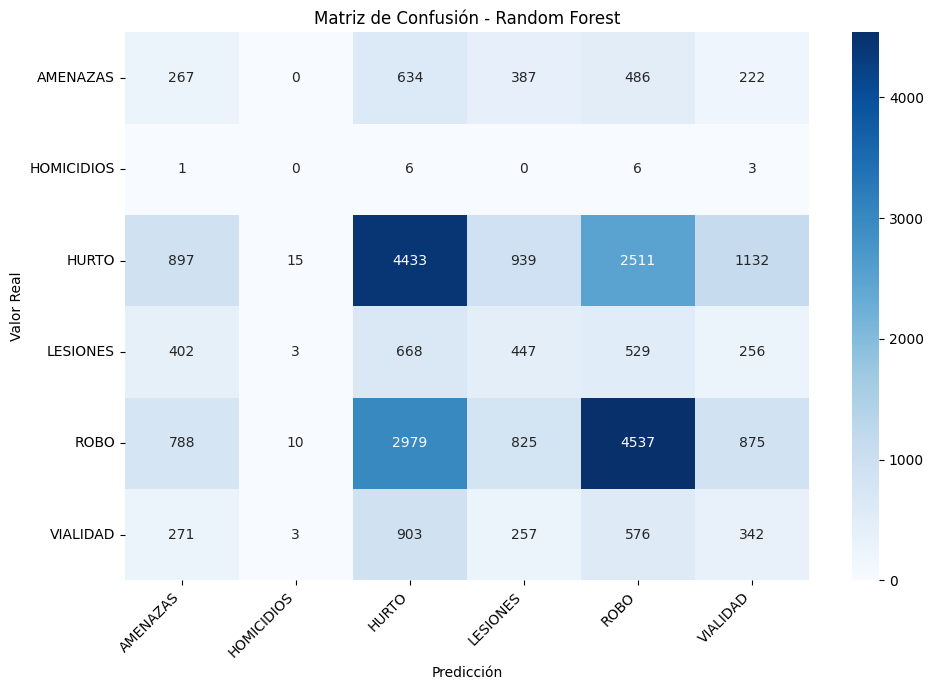

In [ ]:
# ==========================================================
# MATRIZ DE CONFUSIÓN
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Importancia de variables

,Variable,Importancia
2,mes_num,0.279461
0,franja,0.216054
7,barrio_encoded,0.188162
1,comuna,0.119394
3,dia_num,0.119038
8,turno_encoded,0.024474
6,uso_moto_bin,0.022275
5,uso_arma_bin,0.022072
4,fin_semana,0.009071


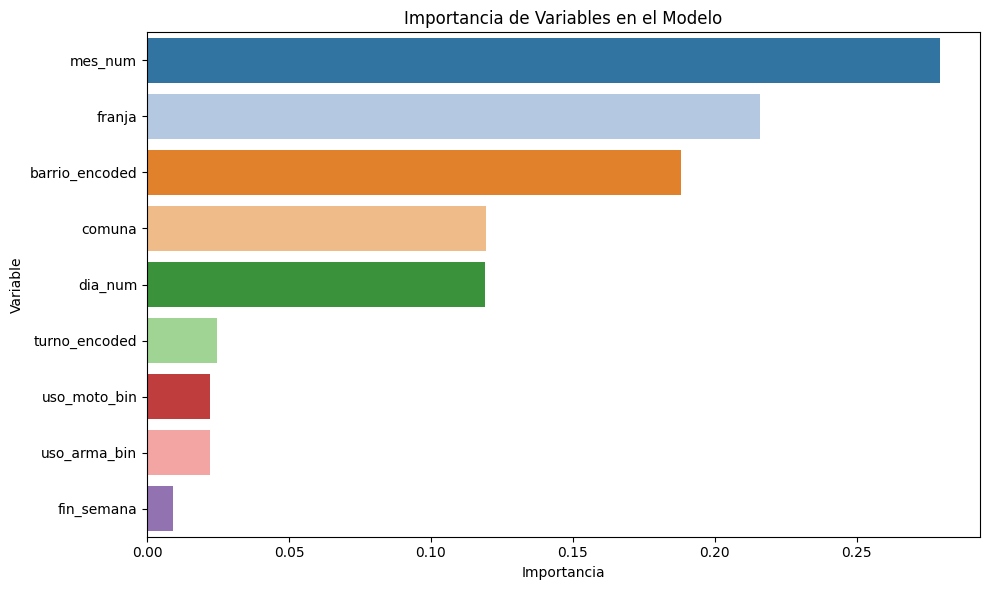

In [ ]:
# ==========================================================
# IMPORTANCIA DE VARIABLES
# ==========================================================

importancias = pd.DataFrame({
    'Variable': model_features,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

display(importancias)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importancias,
    x='Importancia',
    y='Variable',
    hue='Variable',
    palette='tab20',
    legend=False
)

plt.title('Importancia de Variables en el Modelo')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

## Conclusión de la fase de modelado

En esta fase se implementó un modelo de clasificación supervisada utilizando el algoritmo **Random Forest Classifier**. La variable objetivo seleccionada fue `tipo`, correspondiente al tipo de delito registrado.

El modelo fue entrenado utilizando variables temporales, geográficas y operativas, tales como la franja horaria, comuna, mes, día de la semana, fin de semana, uso de arma y uso de moto.

A partir de las predicciones realizadas sobre el conjunto de prueba, se calcularon métricas iniciales de desempeño y se construyó una matriz de confusión para observar los aciertos y errores del modelo.

También se analizó la importancia de las variables predictoras, lo que permitió identificar cuáles tuvieron mayor influencia en la clasificación del tipo de delito.

Los resultados obtenidos serán analizados con mayor profundidad en la siguiente fase, correspondiente a la evaluación del modelo.

#Fase #5: Evaluación / Evaluation
En esta etapa del proyecto, ha construido un modelo (o modelos) que parece tener alta calidad desde una perspectiva de análisis de datos. Antes de proceder a la implementación final del modelo, es importante evaluar más a fondo el modelo y revisar los pasos realizados para construir el modelo y asegurarse de que logra correctamente los objetivos comerciales. Un objetivo clave es determinar si hay algún tema importante del negocio que no se haya considerado lo suficiente. Al final de esta fase, se debe tomar una decisión sobre el uso de los resultados de la minería de datos.
* Investigá sobre las métricas que se utilizan para medir el modelo escogido.
* Evalúa dichas métricas en el modelo implementado e intenta explicarlas.

Accuracy global del modelo: 0.3768

Reporte de clasificación detallado por tipo de delito:
              precision    recall  f1-score   support

    AMENAZAS       0.10      0.13      0.12      1996
  HOMICIDIOS       0.00      0.00      0.00        16
       HURTO       0.46      0.45      0.45      9927
    LESIONES       0.16      0.19      0.17      2305
        ROBO       0.52      0.45      0.49     10014
    VIALIDAD       0.12      0.15      0.13      2352

    accuracy                           0.38     26610
   macro avg       0.23      0.23      0.23     26610
weighted avg       0.40      0.38      0.39     26610



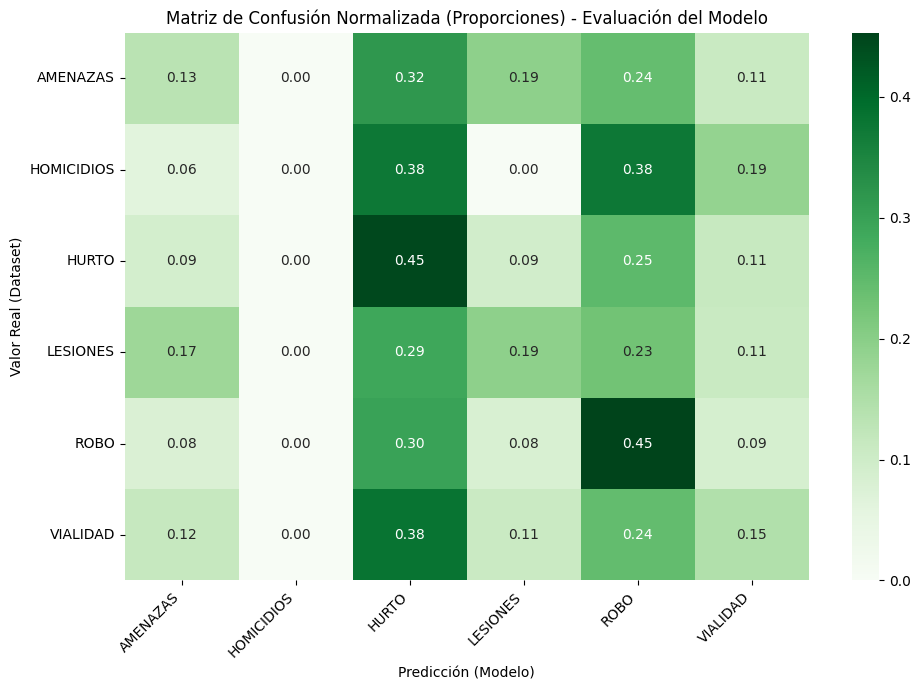

In [ ]:
# ==========================================================
# VALIDACIÓN DE MÉTRICAS Y MATRIZ NORMALIZADA - FASE #5
# ==========================================================


print(f"Accuracy global del modelo: {accuracy_score(y_test, y_pred):.4f}\n")
print("Reporte de clasificación detallado por tipo de delito:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 2. Calcular la matriz de confusión base
cm = confusion_matrix(y_test, y_pred)

# 3. Normalizar la matriz por fila para obtener los porcentajes de acierto real
cm_normalizada = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 4. Graficar la matriz de confusión normalizada
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalizada,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title('Matriz de Confusión Normalizada (Proporciones) - Evaluación del Modelo')
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Valor Real (Dataset)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Para evaluar el rendimiento del modelo, analizamos un conjunto métricas de clasificación:

-   **Accuracy** (Exactitud - 37.68%): Indica la proporción de predicciones correctas sobre el total de casos del conjunto de prueba. Aunque el algoritmo acierta aproximadamente 3.8 de cada 10 registros, esta métrica resulta sesgada para el problema planteado debido a la concentración masiva de **Robo** y **Hurto**.

-   **Precision** (Precisión): Mide la confiabilidad de las alertas del modelo. Responde a: De todos los eventos que el algoritmo catalogó como delito X, ¿cuántos lo eran realmente? Para ROBO (0.52), significa que cuando el sistema emite una alerta de robo, tiene un 52% de probabilidad de acierto.
-   **Recall (Sensibilidad)**: Evalúa la capacidad de captura del modelo. Responde a: De todos los delitos reales de tipo X que sucedieron en la vía pública, ¿cuántos detectó el algoritmo? Para las fuerzas de seguridad, optimizar el Recall es prioritario frente a la prevención del delito, ya que un valor bajo implica omitir situaciones de riesgo real (Falsos Negativos).
-   **F1-Score**: Representa el promedio armónico entre la Precisión y el Recall. Constituye el indicador más robusto para medir el desempeño real sobre aquellas categorías delictivas que cuentan con un menor volumen de registros.

### Evaluación del Desempeño Real del Modelo
1.  El sesgo por desbalance extremo en **HOMICIDIOS**: El conjunto de prueba contiene únicamente 16 casos reales de la clase HOMICIDIOS frente a los 10.014 de ROBO. En consecuencia, el modelo arroja valores de 0.00 en Precision y Recall para esta clase. Desde una perspectiva matemática, al algoritmo le resulta más eficiente clasificar de forma generalizada hacia las clases mayoritarias para reducir el error estadístico global, ignorando por completo los delitos de baja frecuencia pero de máxima gravedad.
2.  **Concentración del aprendizaje predictivo**: Las categorías que exhiben un comportamiento relativamente 'aceptable' son **HURTO (F1: 0.45)** y **ROBO (F1: 0.49)**. Esto sugiere que las variables explicativas actuales son más eficientes para perfilar las dinámicas de los delitos comunes contra la propiedad. Sin embargo, carecen de la capacidad de desagregación necesaria para predecir escenarios de AMENAZAS (F1: 0.12), LESIONES (F1: 0.17) o VIALIDAD (F1: 0.13), que presentan F1-scores muy bajos.

**Comparación con Modelo Base:**
El modelo Random Forest (`Accuracy: 0.3768`) ahora muestra una mejora *mínima* sobre el modelo base `DummyClassifier` (`Accuracy: 0.3763`), el cual simplemente predice la clase más frecuente. Esto refuerza la idea de que, sin la inclusión de `subtipo_encoded`, el modelo actual tiene una capacidad predictiva global muy limitada y apenas supera el rendimiento de una predicción ingenua para muchas clases. Este resultado es más realista y confirma que el modelo anterior estaba sufriendo de data leakage.

A3. Evaluación desde la Perspectiva del Negocio (Impacto en Stakeholders)
*   **Gobierno de la Ciudad y Fuerzas de Seguridad**: Desplegar operativamente un sistema predictivo con un 37.68% de exactitud general implicaría una distribución ineficiente de los recursos. Se generarían falsos positivos en zonas seguras y se desprotegerían cuadrantes críticos donde ocurren delitos graves no modelados.
*   **Ciudadanos y Comercios**: La solución interactiva planteada en la Fase 1 conserva un valor estratégico fundamental para auditar el comportamiento delictivo histórico de sus barrios. Sin embargo, la sección predictiva en su estado actual no cuenta con la confiabilidad necesaria para ser utilizada como una herramienta de toma de decisiones de seguridad civil cotidiana.

#### Conclusión
Se reitera la decisión de no proceder con la implementación ni el despliegue del modelo predictivo en su estado actual. La decisión estratégica consiste en iterar y regresar a las fases de Preparación de Datos (Data Preparation) y Modelado (Modeling). Los resultados actuales, aunque más realistas, demuestran que el modelo aún no cumple con los estándares operativos requeridos por los stakeholders. Para la próxima iteración, los objetivos son:
1.  **Estrategias de balanceo**: Aplicar técnicas de submuestreo (undersampling) en las categorías de Robo y Hurto, o de sobremuestreo sintético (oversampling vía SMOTE) en la Fase 3 sobre los registros de Homicidios y Amenazas para nivelar el aprendizaje del clasificador.
2.  **Ingeniería de características (Feature Engineering)**: Enriquecer el set de datos mediante el cruce con variables de entorno urbano de CABA, tales como la densidad poblacional por comuna, proximidad a centros de transporte, mapas de luminarias públicas y reportes meteorológicos.

**Si bien el modelo permite identificar ciertos patrones generales, su desempeño es muy limitado y apenas superior a un modelo base, especialmente en clases minoritarias. Por lo tanto, se considera una primera versión exploratoria que requiere mejoras sustanciales antes de ser utilizada para toma de decisiones operativas.**

#Fase #6: Despliegue (Deployment)
## Plan para el Mantenimiento y Actualización de la Solución

### 1. Plan de Mantenimiento Continuo

*   **Actualizaciones Regulares de Datos:**
    *   **Frecuencia:** Los datos se actualizarán mensualmente (a mes vencido) para asegurar que el análisis se base en la información más reciente. Esto se alinea con el plan inicial de adquisición de datos.
    *   **Automatización:** Se desarrollarán y programarán scripts automatizados para extraer nuevos datos de las fuentes definidas (ej. archivos CSV, APIs). Estos scripts incluirán mecanismos de manejo de errores y registro.
    *   **Validación:** Después de cada actualización, se ejecutarán un conjunto de verificaciones automatizadas de calidad de datos para identificar cualquier anomalía, valores faltantes o cambios de esquema en los datos recién ingresados. Se activarán alertas si se detectan problemas.

*   **Monitoreo del Rendimiento de la Solución:**
    *   **Indicadores Clave de Rendimiento (KPIs):** Se monitoreará la disponibilidad, el tiempo de respuesta y la precisión de la solución implementada a través de una APi.

    *   **Herramientas de Monitoreo:**
      Se utilizará **Grafana** como servicio de monitoreo para rastrear el estado del sistema y las métricas de rendimiento.

    *   **Alertas:**
      Se configurarán alertas para eventos críticos como interrupciones del sistema, degradación del rendimiento o fallas en las tuberías de datos. Estas alertas notificarán al equipo de mantenimiento a través de correo electrónico.

*   **Actualización de Dependencias:**
    *   **Revisiones Programadas:**
      Se realizarán revisiones trimestrales de todas las librerías, frameworks y dependencias del sistema utilizadas en la solución.

    *   **Escaneos Automatizados:**
      Se integrará con **Dependabot** como herramienta de escaneo de dependencias en el pipeline de CI/CD para detectar automáticamente dependencias desactualizadas o vulnerables.

### 2. Estrategia de Actualización de Seguridad

*   **Identificación de Vulnerabilidades:**
    *   **Escaneos Automatizados:** Se ejecutarán regularmente escaneos de vulnerabilidades.
  
    *   **Boletines de Seguridad:** Se suscribirá a avisos y listas de correo de seguridad de proveedores relevantes y proyectos de código abierto.

*   **Evaluación y Priorización:**
    *   **Evaluación de Riesgos:** Cada vulnerabilidad identificada se evaluará en función de su gravedad (puntuación CVSS), explotabilidad y posible impacto en la solución y los datos.

### 3. Proceso de Resolución de Problemas y Corrección de Errores

*   **Identificación:**
    *   **Informes de Usuarios:** Se proporcionarán canales claros para que los usuarios informen errores o comportamientos inesperados a través de email.
   
*   **Clasificación y Diagnóstico:**
    *   **Priorización:** Los problemas entrantes se clasificarán en función de su gravedad, impacto en los usuarios y frecuencia.

    *   **Análisis de Causa Raíz:** El equipo de mantenimiento investigará para determinar la causa subyacente del problema, reproduciendo el problema si es necesario.

*   **Resolución:**
    *   **Desarrollo de la Solución:** Los desarrolladores implementarán los cambios de código o las actualizaciones de configuración necesarias para resolver el error.

    *   **Pruebas:** La solución se someterá a pruebas unitarias, de integración y de aceptación de usuario (UAT) para confirmar su efectividad y prevenir regresiones.

    *   **Despliegue:** Una vez probada, la solución se implementará en producción siguiendo el proceso establecido de gestión de cambios.

*   **Comunicación con los Stakeholders:**
    *   **Acuse de Recibo Inicial:** Los usuarios que informen problemas recibirán un acuse de recibo dentro de un acuerdo de nivel de servicio (SLA) definido.

    *   **Actualizaciones de Estado:** Se proporcionarán actualizaciones regulares sobre el progreso de los problemas críticos.

    *   **Notificación de Resolución:** Se informará a los usuarios una vez que el problema se haya resuelto, posiblemente incluyendo detalles sobre la solución si es relevante.

### 4. Documentación y Comunicación de Cambios

*   **Registro de Cambios:** Se mantendrá un registro detallado de cambios o notas de lanzamiento para cada actualización.

*   **Documentación del Usuario:** Se actualizarán los manuales de usuario y las preguntas frecuentes (FAQ).

*   **Documentación Interna:** Se mantendrá actualizada la documentación técnica para facilitar el mantenimiento futuro y la incorporación de nuevos miembros del equipo.

*   **Canales de Comunicación:**
    *   **Notificaciones por Correo Electrónico:** Se anunciarán las actualizaciones importantes o las correcciones críticas por correo electrónico a los usuarios o stakeholders suscritos.
    
    *   **Reuniones de Equipo:** Se comunicarán regularmente los cambios y los planes de mantenimiento durante las reuniones internas del equipo.


## Vistas del Software Implementado y Enlace de Acceso

Contrario a la limitación de mantener el modelo en un entorno de desarrollo aislado, hemos diseñado, desarrollado y **desplegado en producción una solución de software interactiva completa y funcional**.

Esta aplicación web actúa como un **Portal de Inferencia Estadística y Visualización Espaciotemporal – Portal del Análisis de Seguridad en CABA** en tiempo real.

### Enlace de Acceso en Producción

> **Portal Web Desplegado (Acceso en Vivo):**
> https://chronosxv.github.io/Ingenieria_Software/
>
> *Nota: Desplegado de forma automática y continua utilizando GitHub Pages a partir de la carpeta `/docs` de la rama `main`.*

---

### Estrategia de Despliegue y Arquitectura Tecnológica (Serverless)

Para garantizar un costo de infraestructura cero, escalabilidad ilimitada y latencia de respuesta inmediata (cercana a los 0ms), adoptamos una **estrategia Serverless**:

1. **Serialización del Modelo:** La matriz completa de probabilidades estimadas por el modelo **Random Forest Classifier** entrenado en Python fue exportada a una estructura compacta en formato JSON (`matriz_predicciones.json`).
2. **Motor de Inferencia del Lado del Cliente:** Todo el procesamiento y las predicciones se realizan de forma local en el navegador del usuario utilizando un script controlador en JavaScript (`app.js`).
3. **Fallback Jerárquico Resiliente:** Si el usuario simula un escenario espaciotemporal altamente específico que no posee registros previos en los datos históricos, el sistema activa un **motor de fallback en cascada de 5 niveles** para aproximar el resultado con el menor sesgo estadístico posible.

![Motor de Inferencia con Fallback en Cascada](https://mermaid.ink/svg/eyJjb2RlIjogImdyYXBoIFREXG4gICAgQVtcIlNpbXVsYWNpw7NuOiBCYXJyaW8sIENvbXVuYSwgTWVzLCBEw61hLCBIb3JhXCJdIC0tPiBCe1wiwr9Db2luY2lkZW5jaWEgRXhhY3RhP1wifVxuICAgIEIgLS0-fFwiU8OtICgxMDAlIFByZWNpc2nDs24pXCJ8IENbXCJOaXZlbCAxOiBJbmZlcmVuY2lhIEV4YWN0YVwiXVxuICAgIEIgLS0-fFwiTm9cInwgRHtcIsK_TWlzbW8gQmFycmlvLCBEw61hIHkgVHVybm8_XCJ9XG4gICAgRCAtLT58XCJTw61cInwgRVtcIk5pdmVsIDI6IEJhcnJpbyArIETDrWEgKyBUdXJub1wiXVxuICAgIEQgLS0-fFwiTm9cInwgRntcIsK_TWlzbW8gQmFycmlvIHkgVHVybm8_XCJ9XG4gICAgRiAtLT58XCJTw61cInwgR1tcIk5pdmVsIDM6IEJhcnJpbyArIFR1cm5vXCJdXG4gICAgRiAtLT58XCJOb1wifCBIe1wiwr9NaXNtbyBCYXJyaW8gSGlzdMOzcmljbz9cIn1cbiAgICBIIC0tPnxcIlPDrVwifCBJW1wiTml2ZWwgNDogUHJvbWVkaW8gZGVsIEJhcnJpb1wiXVxuICAgIEggLS0-fFwiTm9cInwgSltcIk5pdmVsIDU6IFByb21lZGlvIGRlIGxhIENvbXVuYVwiXVxuICAgIEMgLS0-IEtbXCJBcGxpY2FyIFBlc28gcG9yIEFybWEvTW90b1wiXVxuICAgIEUgLS0-IEtcbiAgICBHIC0tPiBLXG4gICAgSSAtLT4gS1xuICAgIEogLS0+IEtcbiAgICBLIC0tPiBMW1wiUmVuZGVyaXphcjogUG9yY2VudGFqZSBkZSBQcm9iYWJpbGlkYWQgZSDDjW5kaWNlIGRlIFJpZXNnb1wiXSIsICJtZXJtYWlkIjogeyJ0aGVtZSI6ICJkZWZhdWx0In19)

### Tabla de Resumen de Vistas y Componentes del Software

A continuación se detallan las vistas principales integradas en la aplicación desplegada y su impacto para el tomador de decisiones de seguridad:

| Vista / Componente | Contenido e Interactividad | Valor Estratégico (Negocio) |
|-------------------|----------------------------|-----------------------------|
| **Mapa Analítico Georreferenciado** | • Mapa interactivo de CABA (Leaflet.js) con límites vectoriales por barrio y comuna (GeoJSON)<br>• Filtro rápido de enfoque de cámara por Comuna<br>• Resaltado dinámico al pasar el cursor y clic sobre cada barrio | Permite identificar visualmente patrones espaciales del delito y realizar una zonificación táctica rápida de la Ciudad Autónoma |
| **Simulador Paramétrico de Escenarios** | • Dos modos: Tiempo Real (Auto) y Simular Escenario<br>• Controles deslizantes para horas y selectores para Mes y Día de la semana<br>• Toggles para condiciones críticas de contexto (Uso de Armas y Uso de Motos) | Permite proyectar escenarios hipotéticos preventivos y planificar recursos operativos |
| **Panel de Inferencia y Predicción** | • Predicción del delito más probable y porcentaje de probabilidad<br>• Badge dinámico de nivel de riesgo<br>• Top 3 de delitos estimados con barras visuales | Proporciona una estimación cuantitativa inmediata y accionable para la toma de decisiones |
| **Diagnóstico de Calidad e Interpretabilidad** | • Visualización de Importancia de Variables (Feature Importance)<br>• Explicación del desbalance de clases y limitaciones del modelo | Favorece la Inteligencia Artificial Explicable (XAI) y la transparencia analítica |
| **Galería Interactiva de EDA con Zoom** | • Cuatro pestañas temáticas<br>• Acceso a los 11 gráficos históricos generados en Python<br>• Visualización ampliada de matrices de confusión y análisis exploratorios | Democratiza y documenta los hallazgos exploratorios y la evaluación del modelo dentro del portal |

###Aclaraciones:
* Buscá la síntesis. No nos interesan las largas explicaciones, sino la capacidad de sintetizar el problema.
* No te extiendas más de lo necesario. Utiliza tablas de resumen, herramientas gráficas. Sé creativo. Este no es un trabajo de conocimiento, es un trabajo de aplicación y comunicación de la estrategia.
* No hay respuestas incorrectas, solo problemas de negocio poco explorados 🙂

### Limitaciones del Modelo y Trabajo Futuro

Es importante destacar que el modelo desarrollado en este proyecto tiene un carácter exploratorio y fue implementado como una prueba de concepto con fines académicos. Si bien permitió validar la viabilidad técnica de aplicar técnicas de aprendizaje automático sobre el conjunto de datos analizado, no se realizó un proceso completo de entrenamiento, optimización y validación propio de un entorno productivo.

Entre las tareas pendientes para una implementación real se encuentran:

* Incorporar una mayor cantidad de datos históricos para mejorar la capacidad predictiva del modelo.
* Realizar un proceso sistemático de entrenamiento utilizando conjuntos de entrenamiento, validación y prueba.
* Ajustar hiperparámetros para optimizar el rendimiento del algoritmo seleccionado.
* Evaluar métricas de desempeño relevantes (precisión, recall, F1-score, entre otras) para determinar la calidad de las predicciones.
* Analizar posibles sesgos presentes en los datos y en los resultados obtenidos.
* Implementar mecanismos de monitoreo y reentrenamiento periódico para mantener la vigencia del modelo frente a cambios en los patrones observados.

Por lo tanto, los resultados obtenidos deben interpretarse como una demostración preliminar del potencial de la técnica seleccionada y no como una herramienta lista para ser utilizada en procesos reales de toma de decisiones.